In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import csv

BASE = '../imc-prosperity-4-backtester/prosperity4bt/resources/round1'
DAYS = ['-2', '-1', '0']

price_rows = []
trade_rows = []
offset = 0

for day in DAYS:
    with open(f'{BASE}/prices_round_1_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    with open(f'{BASE}/trades_round_1_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
trades = pd.DataFrame(trade_rows)

for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')
trades['timestamp'] = pd.to_numeric(trades['timestamp'], errors='coerce')
trades['price']     = pd.to_numeric(trades['price'],     errors='coerce')
trades['quantity']  = pd.to_numeric(trades['quantity'],  errors='coerce')

root_prices = prices[prices['product'] == 'INTARIAN_PEPPER_ROOT'].copy()
root_trades = trades[trades['symbol'] == 'INTARIAN_PEPPER_ROOT'].copy()

print(f'price rows: {len(root_prices)}  trade rows: {len(root_trades)}')
print(root_trades.head())

price rows: 29946  trade rows: 1011
    timestamp buyer seller                symbol currency    price  quantity
2        1000               INTARIAN_PEPPER_ROOT   XIRECS   9995.0         7
4        4000               INTARIAN_PEPPER_ROOT   XIRECS  10007.0         7
6       10500               INTARIAN_PEPPER_ROOT   XIRECS  10013.0         5
7       12600               INTARIAN_PEPPER_ROOT   XIRECS  10018.0         3
11      15000               INTARIAN_PEPPER_ROOT   XIRECS  10021.0         7


In [2]:
# ── Spread = ask - bid ───────────────────────────────────────────────────────
root_prices['spread'] = root_prices['ask_price_1'] - root_prices['bid_price_1']

print(root_prices['spread'].describe())
print(f'most common spreads:')
print(root_prices['spread'].value_counts().head(10).to_string())

count    27688.000000
mean        13.046699
std          2.627145
min          2.000000
25%         12.000000
50%         13.000000
75%         14.000000
max         21.000000
Name: spread, dtype: float64
most common spreads:
spread
13.0    6355
12.0    6138
14.0    4752
11.0    3069
16.0    2058
15.0    1895
17.0    1574
3.0      373
2.0      282
18.0     219


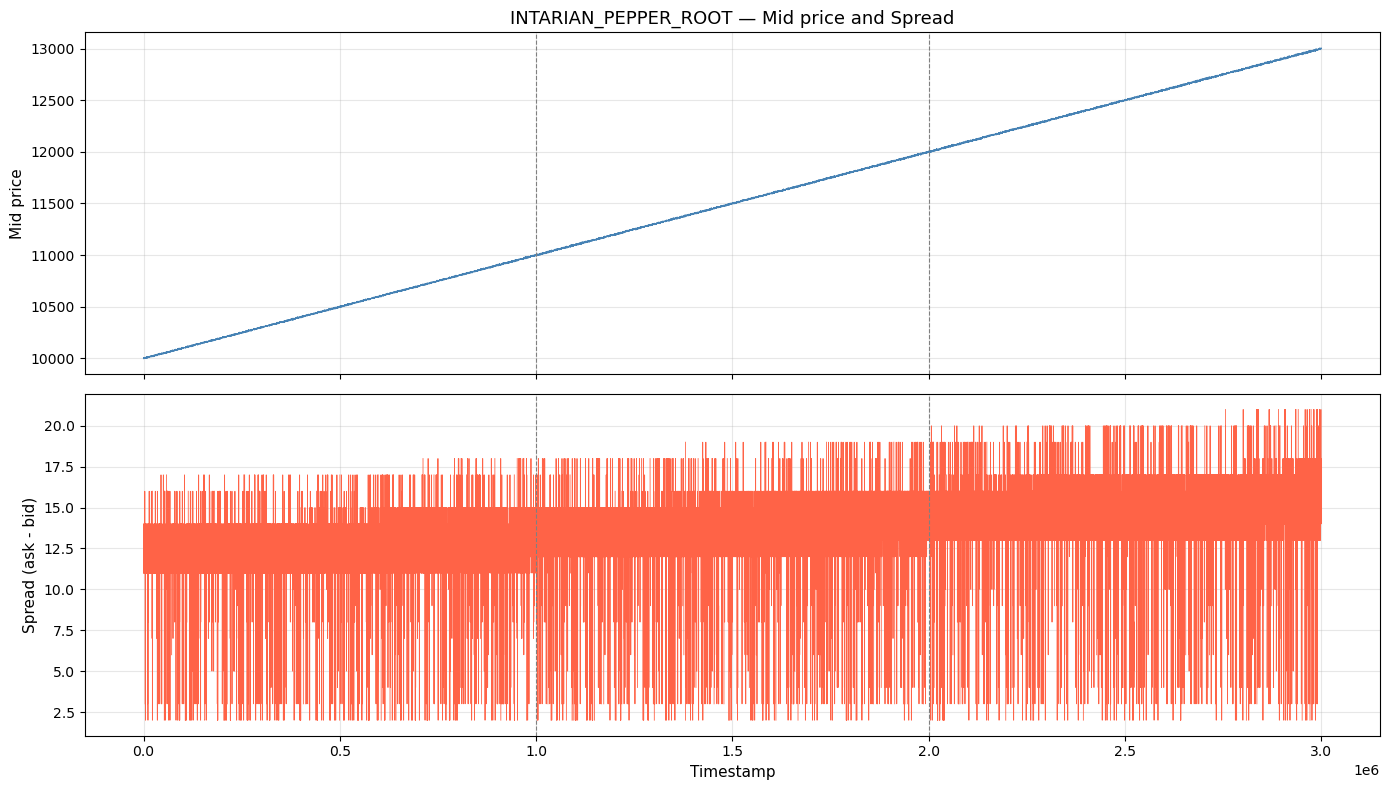

In [3]:
# ── Spread over time ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax = axes[0]
ax.plot(root_prices['timestamp'], root_prices['mid_price'], lw=0.8, color='steelblue')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
ax.set_ylabel('Mid price', fontsize=11)
ax.set_title('INTARIAN_PEPPER_ROOT — Mid price and Spread', fontsize=13)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(root_prices['timestamp'], root_prices['spread'], lw=0.6, color='tomato')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Timestamp', fontsize=11)
ax.set_ylabel('Spread (ask - bid)', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

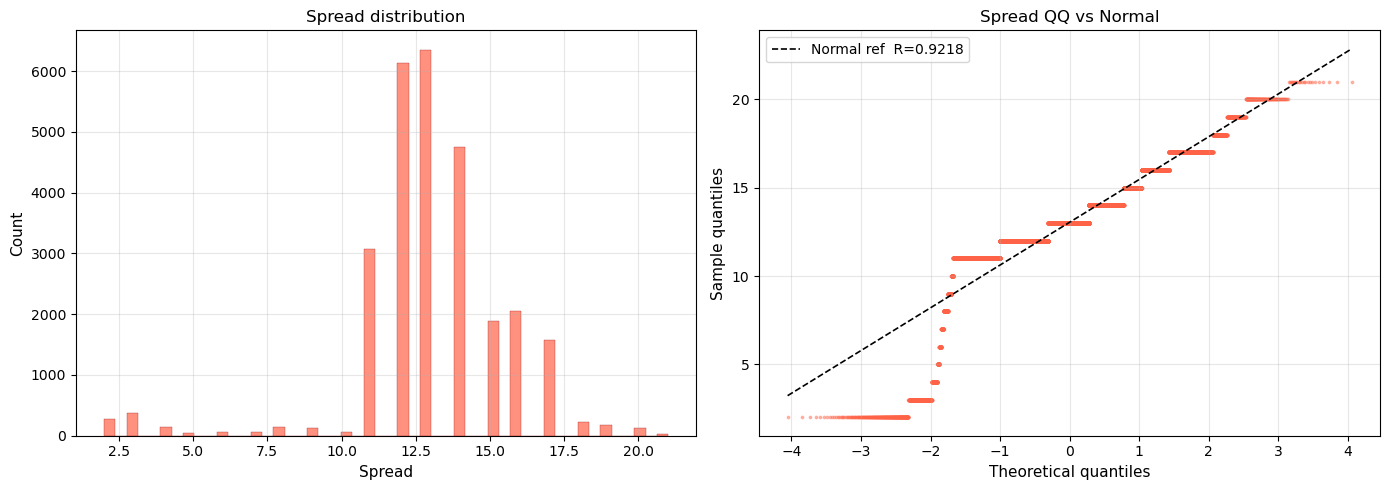

In [4]:
# ── Spread distribution ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(root_prices['spread'].dropna(), bins=50, color='tomato', alpha=0.7, edgecolor='darkred', lw=0.3)
ax.set_xlabel('Spread', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Spread distribution', fontsize=12)
ax.grid(True, alpha=0.3)

ax = axes[1]
spread = root_prices['spread'].dropna()
(osm, osr), (slope, intercept, r) = stats.probplot(spread, dist='norm', plot=None)
ax.scatter(osm, osr, s=3, alpha=0.4, color='tomato')
lx = np.array([osm.min(), osm.max()])
ax.plot(lx, slope * lx + intercept, 'k--', lw=1.2, label=f'Normal ref  R={r:.4f}')
ax.set_xlabel('Theoretical quantiles', fontsize=11)
ax.set_ylabel('Sample quantiles', fontsize=11)
ax.set_title('Spread QQ vs Normal', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

count    1011.000000
mean       -0.377349
std         5.512389
min       -10.500000
25%        -6.000000
50%         0.000000
75%         6.000000
max        10.000000
Name: trade_vs_mid, dtype: float64
trades at or above ask: 48.7%
trades at or below bid: 51.2%


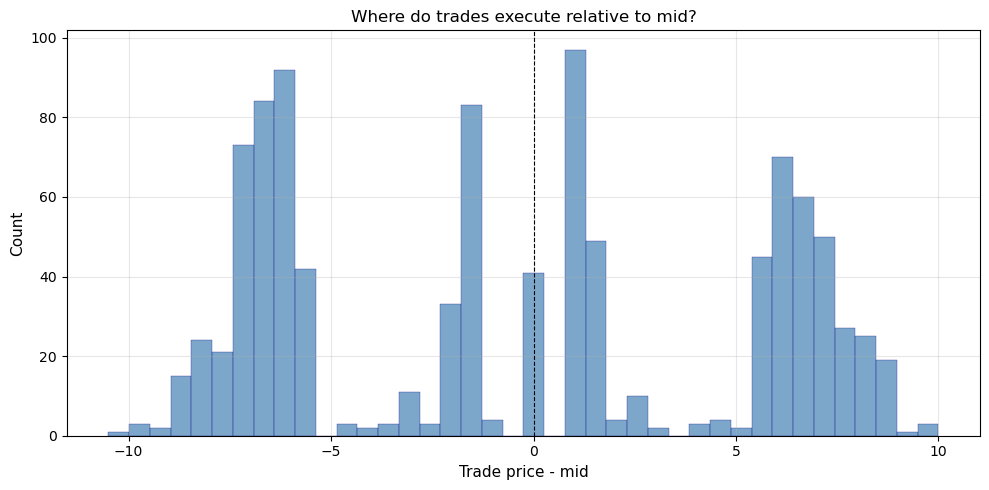

In [5]:
# ── Trade prices vs mid ──────────────────────────────────────────────────────
merged = pd.merge_asof(
    root_trades.sort_values('timestamp'),
    root_prices[['timestamp', 'mid_price', 'bid_price_1', 'ask_price_1']].sort_values('timestamp'),
    on='timestamp', direction='nearest'
)
merged['trade_vs_mid'] = merged['price'] - merged['mid_price']

print(merged['trade_vs_mid'].describe())
print(f'trades at or above ask: {(merged["price"] >= merged["ask_price_1"]).mean()*100:.1f}%')
print(f'trades at or below bid: {(merged["price"] <= merged["bid_price_1"]).mean()*100:.1f}%')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(merged['trade_vs_mid'].dropna(), bins=40, color='steelblue', alpha=0.7, edgecolor='navy', lw=0.3)
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Trade price - mid', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Where do trades execute relative to mid?', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

slope     = 1.059e-03
intercept = 11.4563
R^2       = 0.121807
p-value   = 0.0000000000e+00


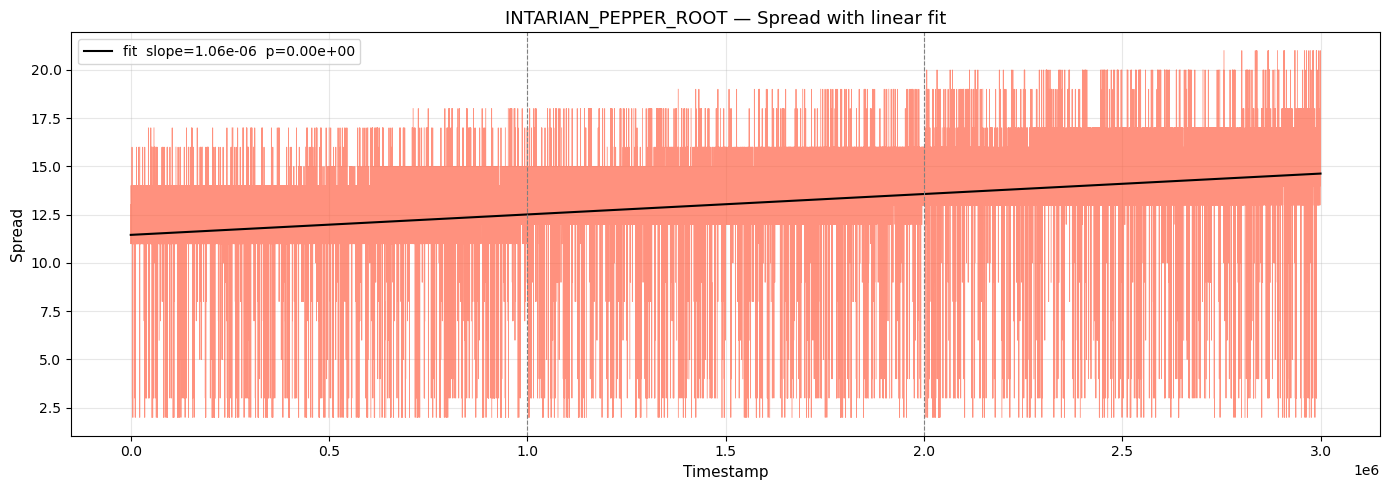

In [12]:
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress

spread = root_prices['spread'].dropna()
ts     = root_prices['timestamp'][spread.index].values

slope, intercept, r, pval, se = linregress(ts, spread)
real_slope = 1000 * slope 
print(f'slope     = {real_slope:.3e}')
print(f'intercept = {intercept:.4f}')
print(f'R^2       = {r**2:.6f}')
print(f'p-value   = {pval:.10e}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(root_prices['timestamp'], root_prices['spread'], lw=0.6, color='tomato', alpha=0.7)
ax.plot(ts, intercept + slope * ts, color='black', lw=1.5, label=f'fit  slope={slope:.2e}  p={pval:.2e}')
for sep in [1_000_000, 2_000_000]:
    ax.axvline(sep, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Timestamp', fontsize=11)
ax.set_ylabel('Spread', fontsize=11)
ax.set_title('INTARIAN_PEPPER_ROOT — Spread with linear fit', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
